# Boo Who? · Phase 3: an Owl for any clue combination

In version 2 the player finds clues with the lantern **in any order**. The six networks from notebook 02 only work when clues arrive in one fixed order, so here we train **one small network for every combination** of the six clues (2^6 - 1 = 63 networks). The game uses them to decide which monster cards to flip down and where the Owl tells you to shine.

**Inputs:** `../data/clean/` · **Outputs:** `../web/data/owl_subsets.json`, `../reports/figures/owl_subsets.png`

In [1]:
import json, itertools, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

CLEAN = Path('../data/clean'); WEB = Path('../web/data'); FIGS = Path('../reports/figures')
prep = json.loads((CLEAN / 'preprocessing.json').read_text())
NUM, COLORS, CLASSES, FEATURES = prep['numeric'], prep['colors'], prep['classes'], prep['features']
CLUE_ORDER = ['hair', 'aura', 'color', 'height', 'rot', 'blood']           # same order and names as notebook 02
CLUES = {'height': ['height'], 'hair': ['hairLength'], 'color': [f'color_{c}' for c in COLORS],
         'aura': ['aura'], 'blood': ['bloodCoverage'], 'rot': ['rottingFleshPct']}
SEED = 42
train = pd.read_csv(CLEAN / 'train_scaled.csv')
X = train[FEATURES].values; y = train['class'].map({c: i for i, c in enumerate(CLASSES)}).values
idx_tr, idx_te = train_test_split(np.arange(len(train)), test_size=0.2, stratify=y, random_state=SEED)   # same split as notebook 02
Xtr, Xte, ytr, yte = X[idx_tr], X[idx_te], y[idx_tr], y[idx_te]
col = {f: i for i, f in enumerate(FEATURES)}
print(len(idx_tr), 'train /', len(idx_te), 'test monsters')

29997 train / 7500 test monsters


## Train one network per clue combination

In [2]:
nets, rows = {}, []
t0 = time.time()
for mask in range(1, 64):
    clues = [c for i, c in enumerate(CLUE_ORDER) if mask >> i & 1]
    feats = [f for c in clues for f in CLUES[c]]; cols = [col[f] for f in feats]
    m = MLPClassifier((32, 16), max_iter=500, early_stopping=True, random_state=SEED).fit(Xtr[:, cols], ytr)
    proba = m.predict_proba(Xte[:, cols])
    nets[mask] = {'clues': clues, 'features': feats, 'cols': cols, 'mlp': m, 'proba': proba}
    rows.append({'mask': mask, 'clues': ', '.join(clues), 'n': len(clues), 'accuracy': accuracy_score(yte, proba.argmax(1))})
table = pd.DataFrame(rows).set_index('mask')
print(f'trained 63 networks in {time.time() - t0:.0f} s')
table.groupby('n')['accuracy'].agg(['min', 'mean', 'max']).round(3)

trained 63 networks in 110 s


,min,mean,max
n,,,
1,0.399,0.517,0.672
2,0.453,0.632,0.841
3,0.517,0.726,0.871
4,0.602,0.797,0.894
5,0.779,0.852,0.893
6,0.891,0.891,0.891


In [3]:
table.sort_values('accuracy', ascending=False).head(8).round(3)

,clues,n,accuracy
mask,,,
60,"color, height, rot, blood",4,0.894
61,"hair, color, height, rot, blood",5,0.893
62,"aura, color, height, rot, blood",5,0.893
63,"hair, aura, color, height, rot, blood",6,0.891
59,"hair, aura, height, rot, blood",5,0.880
58,"aura, height, rot, blood",4,0.877
55,"hair, aura, color, rot, blood",5,0.875
53,"hair, color, rot, blood",4,0.873


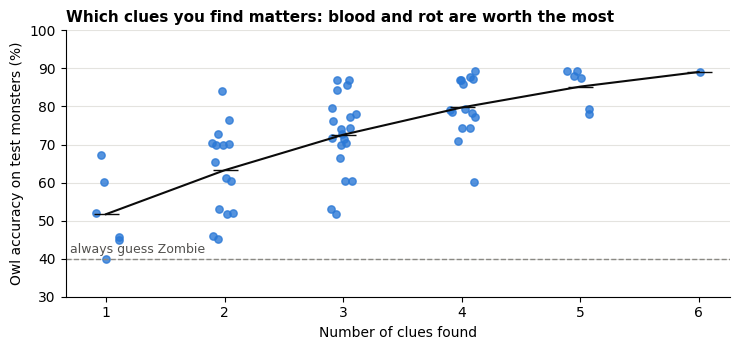

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for n, g in table.groupby('n'):
    ax.scatter(np.full(len(g), n) + np.random.default_rng(n).uniform(-0.12, 0.12, len(g)), g['accuracy'] * 100, s=28, color='#2a78d6', alpha=0.8)
means = table.groupby('n')['accuracy'].mean() * 100
ax.plot(means.index, means.values, color='#0b0b0b', linewidth=1.5, marker='_', markersize=18)
ax.axhline(39.9, color='#8a8984', linestyle='--', linewidth=1); ax.text(0.7, 41.5, 'always guess Zombie', color='#52514e', fontsize=9)
ax.set_xticks(range(1, 7)); ax.set_xlabel('Number of clues found'); ax.set_ylabel('Owl accuracy on test monsters (%)'); ax.set_ylim(30, 100)
ax.set_title('Which clues you find matters: blood and rot are worth the most', loc='left', fontweight='bold', fontsize=11)
ax.spines[['top', 'right']].set_visible(False); ax.yaxis.grid(True, color='#e4e3df'); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGS / 'owl_subsets.png', bbox_inches='tight', dpi=110); plt.show()

## When should a card flip down?

A card flips down when the Owl gives that monster less than a threshold probability. Too high and the true monster's card flips down too often; too low and nothing flips. We check both on the test monsters, averaged over all clue combinations with 1 to 5 clues.

In [5]:
res = []
for t in [0.02, 0.04, 0.06, 0.08, 0.10, 0.15]:
    wrong, flipped = [], []
    for mask, n in nets.items():
        if len(n['clues']) == 6: continue
        p = n['proba']
        wrong.append((p[np.arange(len(yte)), yte] < t).mean())
        flipped.append((p < t).sum(1).mean())
    res.append({'threshold': t, 'true card flipped (%)': np.mean(wrong) * 100, 'cards flipped (avg of 5)': np.mean(flipped)})
thr = pd.DataFrame(res).set_index('threshold'); thr.round(2)

,true card flipped (%),cards flipped (avg of 5)
threshold,,
0.02,0.55,2.04
0.04,1.41,2.36
0.06,2.50,2.60
0.08,3.56,2.76
0.10,4.82,2.91
0.15,8.78,3.22


In [6]:
FLIP_THRESHOLD = 0.06
print(f'Cards flip down below {FLIP_THRESHOLD:.0%}.')

Cards flip down below 6%.


## Export for the game

In [7]:
def layers(mlp):
    return [{'W': np.round(W, 5).tolist(), 'b': np.round(b, 5).tolist()} for W, b in zip(mlp.coefs_, mlp.intercepts_)]
prior = np.bincount(ytr, minlength=5) / len(ytr)
out = {'clue_order': CLUE_ORDER, 'flip_threshold': FLIP_THRESHOLD, 'prior': np.round(prior, 5).tolist(),
       'nets': {str(k): {'features': v['features'], 'layers': layers(v['mlp'])} for k, v in nets.items()},
       'accuracy': {str(k): round(float(r), 4) for k, r in table['accuracy'].items()}}
(WEB / 'owl_subsets.json').write_text(json.dumps(out, separators=(',', ':')))
print('owl_subsets.json:', round((WEB / 'owl_subsets.json').stat().st_size / 1024), 'KB')

owl_subsets.json: 411 KB


## Does the browser give the same answers?

In [8]:
raw = pd.read_csv(CLEAN / 'train_clean.csv').iloc[idx_te[:300]]
mons = [{**{c: float(r[c]) for c in NUM}, 'color': COLORS[int(np.argmax([r[f'color_{c}'] for c in COLORS]))]} for _, r in raw.iterrows()]
Xc = np.column_stack([((pd.Series([m[c] for m in mons]).clip(prep['train_range'][c]['min'], prep['train_range'][c]['max']) - prep['scaler'][c]['mean']) / prep['scaler'][c]['std']) if c in NUM
                      else np.array([float(m['color'] == c.replace('color_', '')) for m in mons]) for c in FEATURES])
masks = [1, 5, 12, 21, 42, 63]
expected = {str(k): nets[k]['mlp'].predict_proba(Xc[:, nets[k]['cols']]).tolist() for k in masks}
Path('owl_check.json').write_text(json.dumps({'monsters': mons, 'expected': expected}))
import subprocess
print(subprocess.run(['node', '../web/tests/owl_check.mjs'], capture_output=True, text=True).stdout)

Compared 1800 predictions. Largest difference: 4.28e-5
PASS: the browser Owl matches Python.

